<a href="https://colab.research.google.com/github/NeuroTune/MRI-Brain-age-prediction-ML/blob/main/MRI_Brain_Age_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Install Nilearn (MRI fetching and plotting)
# Install Nibabel (NIfTI files)
!pip install nilearn nibabel matplotlib

Download the OASIS-1 Dataset

In [4]:
from nilearn import datasets

oasis_dataset = datasets.fetch_oasis_vbm(n_subjects=100)
gray_matter_images = oasis_dataset.gray_matter_maps
metadata = oasis_dataset.ext_vars

print(f"Downloaded {len(gray_matter_images)} images.")
print(metadata.head())

[fetch_oasis_vbm] Dataset found in /root/nilearn_data/oasis1

Downloaded 100 images.
              id mf hand  age  educ  ses  mmse  cdr  etiv   nwbv    asf  delay
0  OAS1_0001_MR1  F    R   74   2.0  3.0  29.0  0.0  1344  0.743  1.306    NaN
1  OAS1_0002_MR1  F    R   55   4.0  1.0  29.0  0.0  1147  0.810  1.531    NaN
2  OAS1_0003_MR1  F    R   73   4.0  3.0  27.0  0.5  1454  0.708  1.207    NaN
3  OAS1_0004_MR1  M    R   28   NaN  NaN   NaN  NaN  1588  0.803  1.105    NaN
4  OAS1_0005_MR1  M    R   18   NaN  NaN   NaN  NaN  1737  0.848  1.010    NaN


Visualize the Data

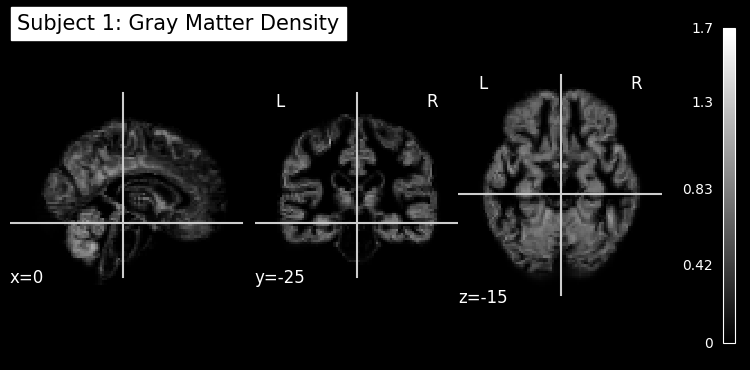

In [7]:
from nilearn import plotting

first_brain = gray_matter_images[0]
plotting.plot_anat(first_brain, title="Subject 1: Gray Matter Density")
plotting.show()

Extract the age column

In [8]:
import pandas as pd
y = metadata['age'].values

print(f"Target ages for first 5 subjects: {y[:5]}")

Target ages for first 5 subjects: [74 55 73 28 18]


Use NiftiMasker to "flatten" the 3D images

In [13]:
from nilearn.maskers import NiftiMasker

masker = NiftiMasker(standardize='zscore_sample', smoothing_fwhm=2, memory='nilearn_cache')

X = masker.fit_transform(gray_matter_images)

print(f"Feature matrix shape: {X.shape}")


Feature matrix shape: (100, 902629)
